In [28]:
import pandas as pd
file_path ="../data/dataset_new/tainning_dataset.csv"
df = pd.read_csv(file_path)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Assuming the DataFrame `df` has the same structure
image_pairs = list(zip(df['img1_path'], df['img2_path']))
style_labels = df['style_label'].tolist()
font_labels = df['font_label'].tolist()

# Now `image_pairs`, `style_labels`, and `font_labels` are reconstructed

df['original_index'] = df.index

In [29]:
import numpy as np
from PIL import Image # Import the PIL library


# Example training data (this is just a placeholder)
# image_pairs = [(img1, img2), (img3, img4), ...]
# style_labels = [0, 1, ...]  # Binary labels for style coherence
# font_labels = [0, 1, ...]   # Binary labels for font similarity

# Convert to numpy arrays
image_pairs = np.array(image_pairs)
style_labels = np.array(style_labels)
font_labels = np.array(font_labels)


In [30]:
#####################################################################
# FULL MEMORY-SAFE SIAMESE MODEL WITH GENERATOR + K-FOLD TRAINING  #
#####################################################################

import numpy as np
import gc
import time
from PIL import Image
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold, train_test_split

from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Lambda
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K


#####################################################################
# IMAGE LOADING
#####################################################################

def load_and_preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((224, 224))
    img = np.array(img, dtype=np.float32) / 255.0
    return img


#####################################################################
# GENERATOR (LOADS IMAGES LAZILY)
#####################################################################

class SiameseGenerator(Sequence):
    def __init__(self, image_pairs, labels, batch_size=8, shuffle=True):
        self.image_pairs = image_pairs
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(image_pairs))
        self.on_epoch_end()

    def __len__(self):
        return len(self.indices) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        idx = self.indices[index * self.batch_size : (index + 1) * self.batch_size]

        imgs1 = []
        imgs2 = []
        labels = []

        for i in idx:
            p1, p2 = self.image_pairs[i]
            imgs1.append(load_and_preprocess_image(p1))
            imgs2.append(load_and_preprocess_image(p2))
            labels.append(self.labels[i])

        return [np.array(imgs1, dtype=np.float32),
                np.array(imgs2, dtype=np.float32)], \
               np.array(labels, dtype=np.float32)


#####################################################################
# SIAMESE ENCODER
#####################################################################

def create_cnn_model(input_shape, branch_name):
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = Dropout(0.5)(x)

    return Model(inp, x, name="shared_siamese_encoder")


#####################################################################
# SIAMESE NETWORK
#####################################################################

import tensorflow as tf
from tensorflow.keras.layers import Input, Lambda, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K


def l2_distance_vector(vectors):
    v1, v2 = vectors
    # compute the element-wise squared difference
    diff = K.square(v1 - v2)
    # return the full vector (not the summed scalar) so the classifier stays unchanged
    return diff


def create_siamese_network(input_shape):
    input_1 = Input(shape=input_shape, name="input_1")
    input_2 = Input(shape=input_shape, name="input_2")

    encoder = create_cnn_model(input_shape, "branch")

    v1 = encoder(input_1)
    v2 = encoder(input_2)

    # proper distance features
    distance_features = Lambda(l2_distance_vector, name="distance_features")([v1, v2])

    x = Dense(128, activation='relu')(distance_features)
    x = Dense(64, activation='relu')(x)

    style_output = Dense(1, activation='sigmoid', name='style_output')(x)

    model = Model(inputs=[input_1, input_2], outputs=style_output)
    model.compile(
        optimizer=Adam(3e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


#####################################################################
# TRAIN/TEST SPLIT (PATHS ONLY)
#####################################################################

X_train, X_test, y_train, y_test = train_test_split(
    image_pairs,
    style_labels,
    test_size=0.2,
    random_state=42,
    stratify=style_labels
)


#####################################################################
# CALLBACKS
#####################################################################

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


#####################################################################
# K-FOLD TRAINING LOOP
#####################################################################

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f"\n--- Training fold {fold+1} ---")

    K.clear_session()
    gc.collect()

    model = create_siamese_network((224, 224, 3))

    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold   = X_train[val_idx]
    y_val_fold   = y_train[val_idx]

    train_gen = SiameseGenerator(X_train_fold, y_train_fold, batch_size=32, shuffle=True)
    val_gen   = SiameseGenerator(X_val_fold,   y_val_fold,   batch_size=32, shuffle=False)

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=100,
        callbacks=[reduce_lr, early_stopping],
        verbose=1
    )

    print(f"--- Fold {fold+1} completed ---")

end_time = time.time()
print("Total training time:", round(end_time - start_time, 2), "seconds")


#####################################################################
# FINAL EVALUATION
#####################################################################

test_gen = SiameseGenerator(X_test, y_test, batch_size=16, shuffle=False)
loss, acc = model.evaluate(test_gen, verbose=0)
print("\nTest accuracy:", round(acc, 4))



--- Training fold 1 ---
Epoch 1/100
120/120 [==============================] - 29s 229ms/step - loss: 3.1016 - accuracy: 0.5406 - val_loss: 2.7877 - val_accuracy: 0.5844 - lr: 3.0000e-04
Epoch 2/100
120/120 [==============================] - 28s 237ms/step - loss: 2.5736 - accuracy: 0.5706 - val_loss: 2.3596 - val_accuracy: 0.6625 - lr: 3.0000e-04
Epoch 3/100
120/120 [==============================] - 51s 431ms/step - loss: 2.1865 - accuracy: 0.5924 - val_loss: 1.9911 - val_accuracy: 0.6729 - lr: 3.0000e-04
Epoch 4/100
120/120 [==============================] - 50s 421ms/step - loss: 1.8692 - accuracy: 0.5984 - val_loss: 1.7230 - val_accuracy: 0.6719 - lr: 3.0000e-04
Epoch 5/100
120/120 [==============================] - 49s 407ms/step - loss: 1.6207 - accuracy: 0.6156 - val_loss: 1.5165 - val_accuracy: 0.6698 - lr: 3.0000e-04
Epoch 6/100
120/120 [==============================] - 48s 382ms/step - loss: 1.4153 - accuracy: 0.6206 - val_loss: 1.3321 - val_accuracy: 0.6667 - lr: 3.0000e-

38/38 [==============================] - 3s 85ms/step
Style Output - Accuracy: 0.74, Precision: 0.66, Recall: 1.00, F1 Score: 0.79
Jaccard Similarity:  0.659316427783903
Cohen's Kappa:  0.485
ROC AUC:  0.7424999999999999


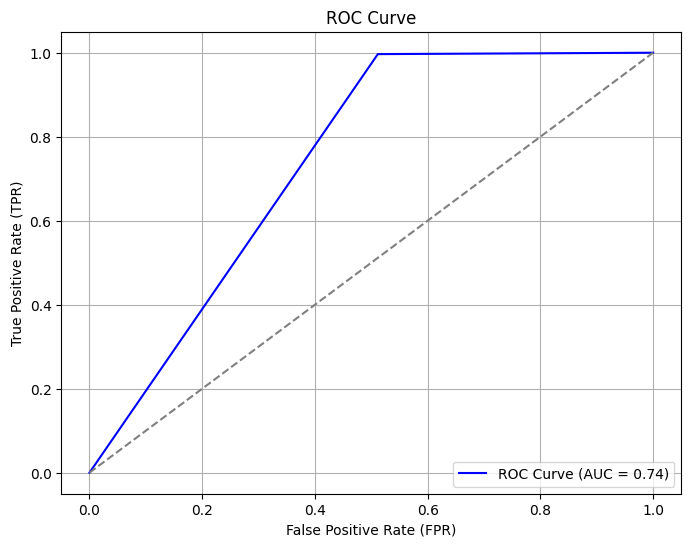

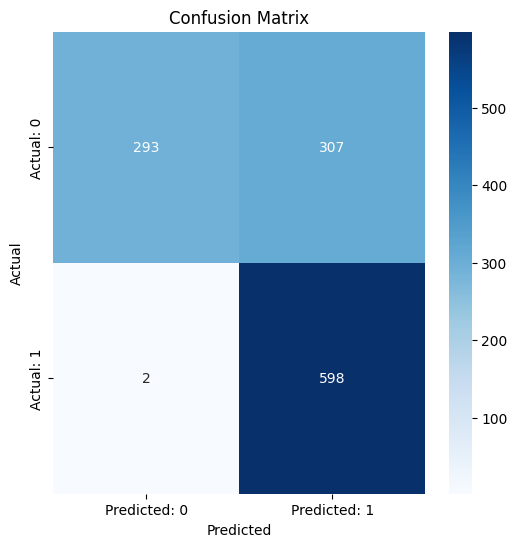

In [35]:
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



#Predict on the validation set
style_pred_val = model.predict([X_test_1, X_test_2])

# Convert predictions to binary values (threshold at 0.5 for binary classification)
style_pred_val = (style_pred_val > 0.5).astype(int)
# # Identify False Positives
# false_positive_indices = [
#     test_indices[i] for i, (true, pred) in enumerate(zip(y_test, style_pred_val)) if true == 0 and pred == 1
# ]

# # Analyze the corresponding attributes
# for idx in false_positive_indices:
#     attributes_img1 = json.loads(df.loc[idx, 'attributes_img1'])
#     attributes_img2 = json.loads(df.loc[idx, 'attributes_img2'])
#     print(f"False Positive Pair {idx}:")
#     print(f"Attributes Image 1: {attributes_img1}")
#     print(f"Attributes Image 2: {attributes_img2}")

# Calculate additional metrics using sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Style output metrics
style_accuracy = accuracy_score(y_test, style_pred_val)
style_precision = precision_score(y_test, style_pred_val)
style_recall = recall_score(y_test, style_pred_val)
style_f1 = f1_score(y_test, style_pred_val)

print(f"Style Output - Accuracy: {style_accuracy:.2f}, Precision: {style_precision:.2f}, Recall: {style_recall:.2f}, F1 Score: {style_f1:.2f}")


from sklearn.metrics import jaccard_score

# Compute Jaccard similarity
jaccard = jaccard_score(y_test, style_pred_val)
print("Jaccard Similarity: ", jaccard)

from sklearn.metrics import cohen_kappa_score

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(y_test, style_pred_val)
print("Cohen's Kappa: ", kappa)

from sklearn.metrics import roc_auc_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, style_pred_val)
print("ROC AUC: ", roc_auc)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, style_pred_val)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, style_pred_val)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted: 0", "Predicted: 1"], yticklabels=["Actual: 0", "Actual: 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()